In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/data.csv')
df.head(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [8]:

df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

In [9]:
print(df.columns.tolist())

['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [10]:
print(df.shape)
print(df['diagnosis'].value_counts())

(569, 33)
diagnosis
0    357
1    212
Name: count, dtype: int64


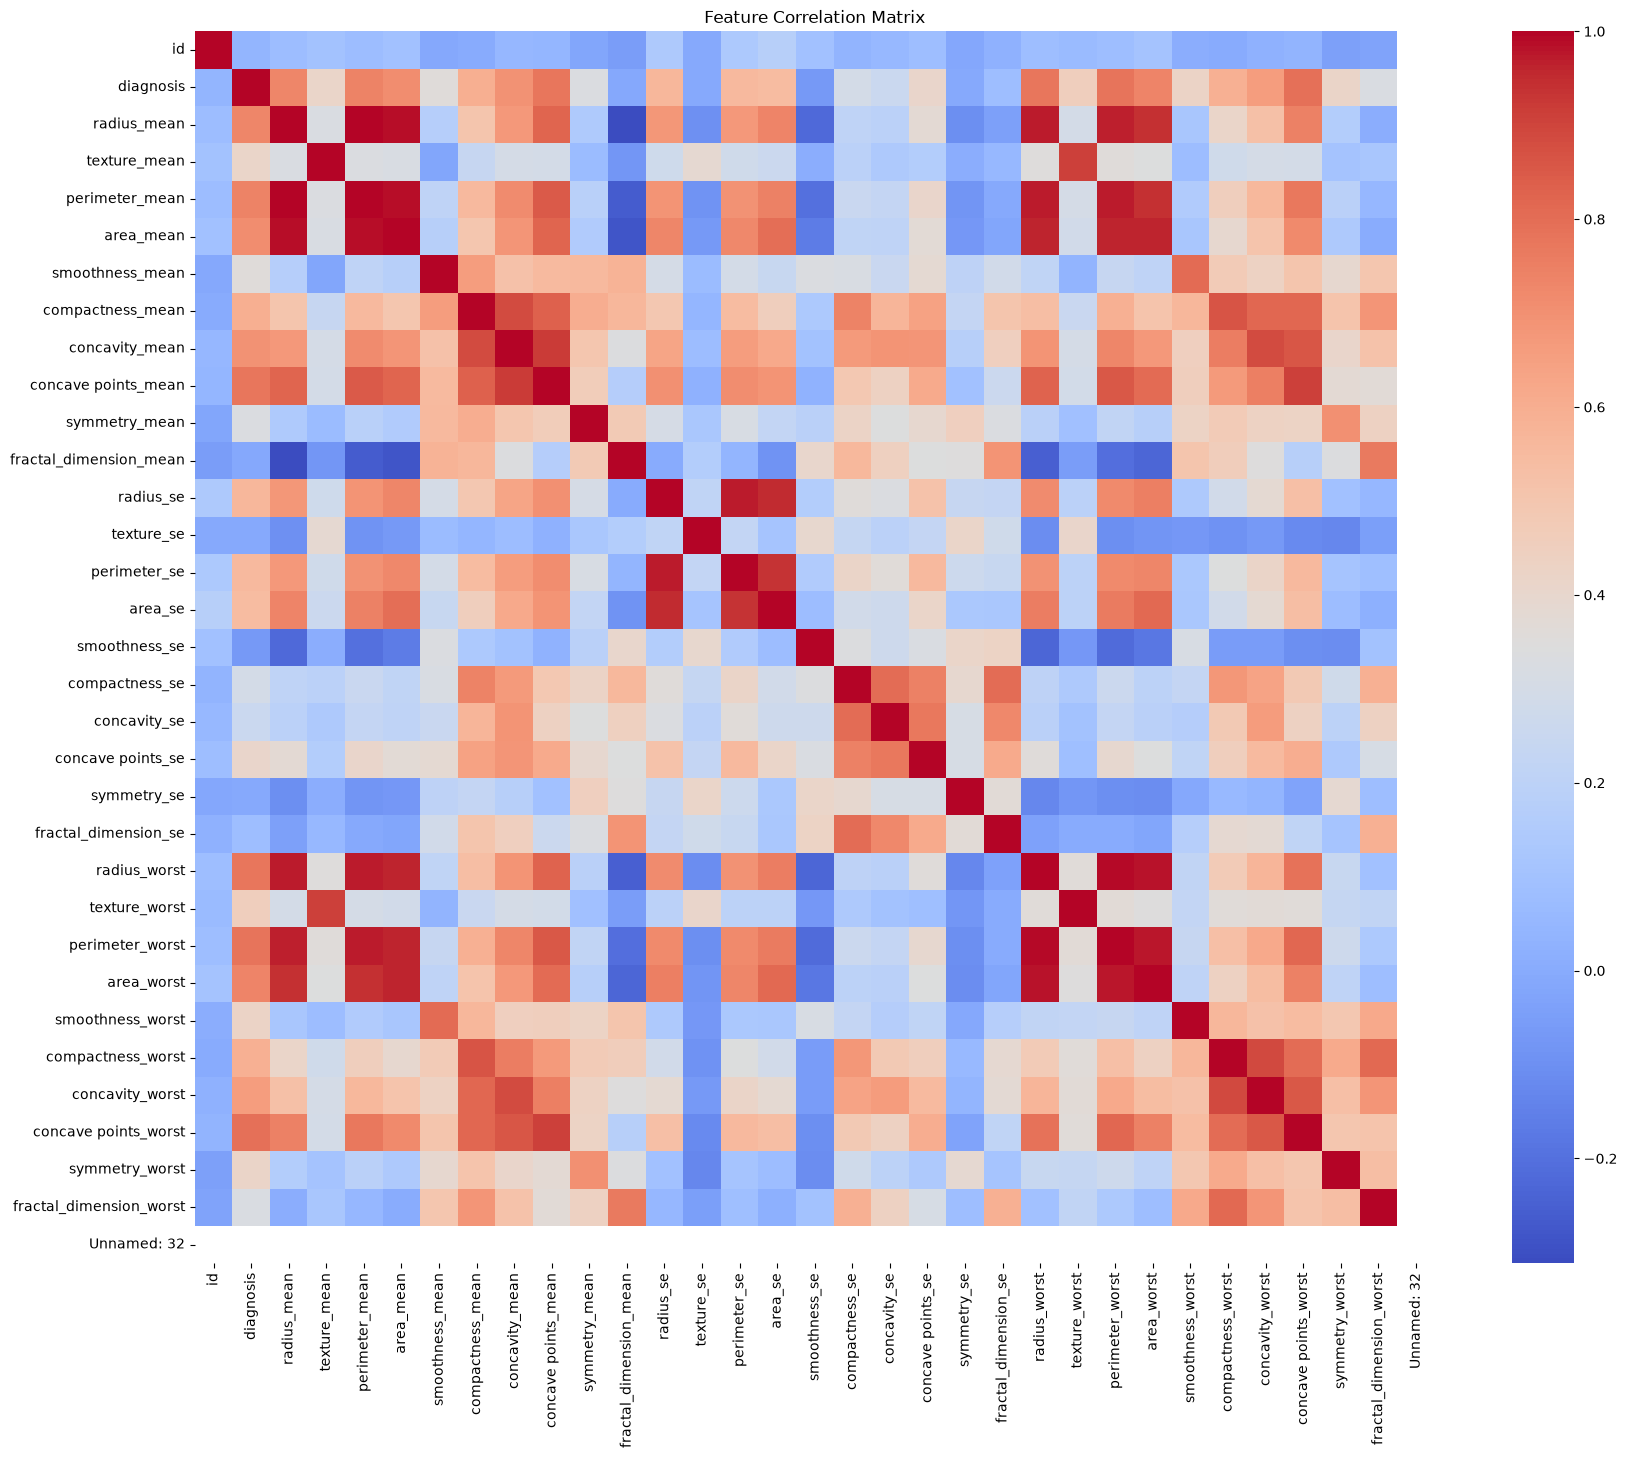

In [11]:
plt.figure(figsize=(20,16))
df.corr()
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt='.1f')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
X = df.drop(['diagnosis'] , axis=1)
y =df['diagnosis']
print(X.shape)
print(y.shape)

(569, 32)
(569,)


In [18]:
df = df.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(455, 32)
(114, 32)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [21]:
print(pipeline)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=10)),
                ('classifier', LogisticRegression(max_iter=1000))])


In [23]:
X_train = X_train.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

In [31]:
X_test = X_test.drop(columns=['Unnamed: 32', 'id'], errors='ignore')

In [24]:
print(X_train.isna().sum())

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [32]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean cross-validation score:", np.mean(cv_scores))
print("Standard deviation of cross-validation scores:", np.std(cv_scores))


Cross-validation scores: [0.98901099 0.96703297 0.97802198 0.97802198 0.96703297]
Mean cross-validation score: 0.9758241758241759
Standard deviation of cross-validation scores: 0.008223422828074603


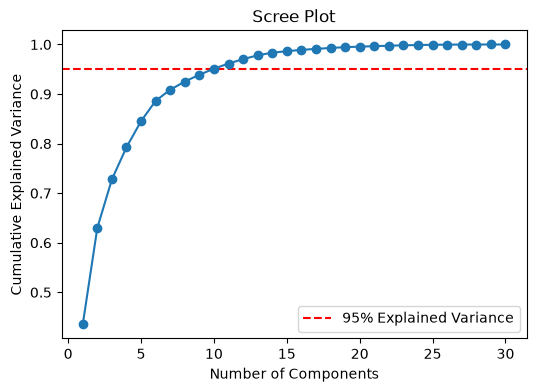

In [33]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
pca = PCA(n_components=30)
pca.fit(X_train_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(6,4))
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o' )
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.legend()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('breast-cancer-pca')

with mlflow.start_run():
    #log parameters
    mlflow.log_param('n_components', 10)
    mlflow.log_param('classifier', 'LogisticRegression')
    mlflow.log_param('max_iter', 1000)
    mlflow.log_param('cv', 5)
    mlflow.log_param('test_size', 0.2)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('scaler', 'StandardScaler')
    mlflow.log_param('pca', 'PCA')
    mlflow.log_param('pipeline', 'StandardScaler + PCA + LogisticRegression')
    mlflow.log_param('dataset', 'breast-cancer-wisconsin')
    mlflow.log_param('target', 'diagnosis')
    
    #log metrics
    mlflow.log_metric('mean_cv_score', np.mean(cv_scores))
    mlflow.log_metric('std_cv_score', np.std(cv_scores))
    mlflow.log_metric('max_cv_score', np.max(cv_scores))
    mlflow.log_metric('min_cv_score', np.min(cv_scores))
    mlflow.log_metric('explained_variance_95', np.sum(explained_variance[:10]))
    mlflow.log_metric('explained_variance_90', np.sum(explained_variance[:9]))
    mlflow.log_metric('explained_variance_85', np.sum(explained_variance[:8]))
    mlflow.log_metric('explained_variance_80', np.sum(explained_variance[:7]))
    mlflow.log_metric('explained_variance_75', np.sum(explained_variance[:6]))
    mlflow.log_metric('explained_variance_70', np.sum(explained_variance[:5]))

    #fit the pipeline
    pipeline.fit(X_train, y_train)

    #Artifacts
    mlflow.sklearn.log_model(pipeline, 'model')
   
    mlflow.log_artifact('scree_plot.png')
    mlflow.log_artifact('correlation_heatmap.png')
    
    
    #save the model
    mlflow.sklearn.log_model(pipeline, 'model')
    print ("Model logged succesfully in mlflow")



2026/07/11 15:40:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 15:40:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model logged succesfully in mlflow


In [35]:
import mlflow
print(mlflow.get_tracking_uri())

sqlite:///mlflow.db


In [36]:
print(mlflow.get_experiment_by_name('breast-cancer-pca'))

<Experiment: artifact_location=('file:///d:/Master in IB&IV/ML '
 'Projects/pca-disease-predictor/notebooks/mlruns/1'), creation_time=1783727817698, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783727817698, lifecycle_stage='active', name='breast-cancer-pca', tags={}, trace_location=None, workspace='default'>


In [37]:
y_pred = pipeline.predict(X_test)

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.98      0.98      0.98        43

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



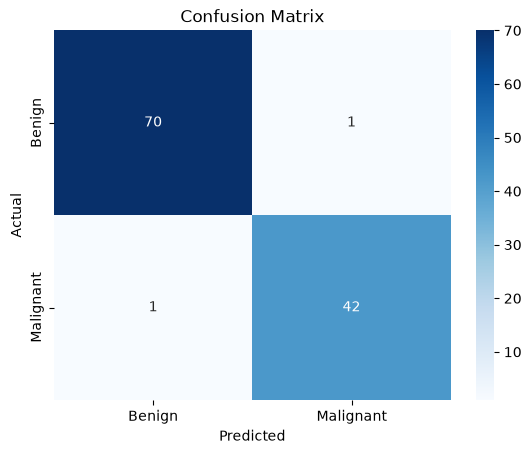

In [39]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

In [40]:
print(confusion_matrix(y_test, y_pred))

[[70  1]
 [ 1 42]]


In [41]:
with mlflow.start_run(run_name='final_evaluation'):
    mlflow.log_metric('test_accuracy', 0.98)
    mlflow.log_metric('malignant_recall', 0.98)
    mlflow.log_metric('malignant_precision', 0.98)
    mlflow.log_metric('false_negatives', 1)
    mlflow.log_metric('false_positives', 1)
    mlflow.log_artifact('confusion_matrix.png')

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 455 entries, 68 to 102
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              455 non-null    float64
 1   texture_mean             455 non-null    float64
 2   perimeter_mean           455 non-null    float64
 3   area_mean                455 non-null    float64
 4   smoothness_mean          455 non-null    float64
 5   compactness_mean         455 non-null    float64
 6   concavity_mean           455 non-null    float64
 7   concave points_mean      455 non-null    float64
 8   symmetry_mean            455 non-null    float64
 9   fractal_dimension_mean   455 non-null    float64
 10  radius_se                455 non-null    float64
 11  texture_se               455 non-null    float64
 12  perimeter_se             455 non-null    float64
 13  area_se                  455 non-null    float64
 14  smoothness_se            455 n

In [43]:
print(X_train.columns.tolist())

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [44]:
print(X_test.iloc[0].to_dict())

{'radius_mean': 12.47, 'texture_mean': 18.6, 'perimeter_mean': 81.09, 'area_mean': 481.9, 'smoothness_mean': 0.09965, 'compactness_mean': 0.1058, 'concavity_mean': 0.08005, 'concave points_mean': 0.03821, 'symmetry_mean': 0.1925, 'fractal_dimension_mean': 0.06373, 'radius_se': 0.3961, 'texture_se': 1.044, 'perimeter_se': 2.497, 'area_se': 30.29, 'smoothness_se': 0.006953, 'compactness_se': 0.01911, 'concavity_se': 0.02701, 'concave points_se': 0.01037, 'symmetry_se': 0.01782, 'fractal_dimension_se': 0.003586, 'radius_worst': 14.97, 'texture_worst': 24.64, 'perimeter_worst': 96.05, 'area_worst': 677.9, 'smoothness_worst': 0.1426, 'compactness_worst': 0.2378, 'concavity_worst': 0.2671, 'concave points_worst': 0.1015, 'symmetry_worst': 0.3014, 'fractal_dimension_worst': 0.0875}


In [45]:
import json
print(json.dumps(X_test.iloc[0].to_dict(), indent=2))

{
  "radius_mean": 12.47,
  "texture_mean": 18.6,
  "perimeter_mean": 81.09,
  "area_mean": 481.9,
  "smoothness_mean": 0.09965,
  "compactness_mean": 0.1058,
  "concavity_mean": 0.08005,
  "concave points_mean": 0.03821,
  "symmetry_mean": 0.1925,
  "fractal_dimension_mean": 0.06373,
  "radius_se": 0.3961,
  "texture_se": 1.044,
  "perimeter_se": 2.497,
  "area_se": 30.29,
  "smoothness_se": 0.006953,
  "compactness_se": 0.01911,
  "concavity_se": 0.02701,
  "concave points_se": 0.01037,
  "symmetry_se": 0.01782,
  "fractal_dimension_se": 0.003586,
  "radius_worst": 14.97,
  "texture_worst": 24.64,
  "perimeter_worst": 96.05,
  "area_worst": 677.9,
  "smoothness_worst": 0.1426,
  "compactness_worst": 0.2378,
  "concavity_worst": 0.2671,
  "concave points_worst": 0.1015,
  "symmetry_worst": 0.3014,
  "fractal_dimension_worst": 0.0875
}


In [46]:
import json

# rename columns to match Pydantic field names
row = X_test.iloc[0].to_dict()
row_fixed = {k.replace(' ', '_'): v for k, v in row.items()}
print(json.dumps(row_fixed, indent=2))

{
  "radius_mean": 12.47,
  "texture_mean": 18.6,
  "perimeter_mean": 81.09,
  "area_mean": 481.9,
  "smoothness_mean": 0.09965,
  "compactness_mean": 0.1058,
  "concavity_mean": 0.08005,
  "concave_points_mean": 0.03821,
  "symmetry_mean": 0.1925,
  "fractal_dimension_mean": 0.06373,
  "radius_se": 0.3961,
  "texture_se": 1.044,
  "perimeter_se": 2.497,
  "area_se": 30.29,
  "smoothness_se": 0.006953,
  "compactness_se": 0.01911,
  "concavity_se": 0.02701,
  "concave_points_se": 0.01037,
  "symmetry_se": 0.01782,
  "fractal_dimension_se": 0.003586,
  "radius_worst": 14.97,
  "texture_worst": 24.64,
  "perimeter_worst": 96.05,
  "area_worst": 677.9,
  "smoothness_worst": 0.1426,
  "compactness_worst": 0.2378,
  "concavity_worst": 0.2671,
  "concave_points_worst": 0.1015,
  "symmetry_worst": 0.3014,
  "fractal_dimension_worst": 0.0875
}


In [47]:
print(y_test.iloc[0])

0


In [51]:
import joblib
joblib.dump(pipeline, '../models/pipeline.pkl')

['../models/pipeline.pkl']

In [52]:
import joblib
joblib.dump(pipeline, '../models/pipeline.pkl')
print("Model saved successfully!")

Model saved successfully!
